# 하수 capacity(관 높이) 재교정 — surcharge 정의 토대 점검

**배경**: surcharge = `fill_rate = 수위 / 관높이(capacity) ≥ 1`. 그런데 진위감사에서 `capacity에러 35센서`(주로 22·23구역)가 나왔다.
"센서가 불량"이 아니라 **capacity가 틀린 것 아닌가?**를 검증한다.

**판정 원리(물리 제약)**: 관 안 물깊이는 관 높이를 넘을 수 없다. 따라서 **수위 중앙값 > 관높이면 그 센서의 '수위'는 관내 물깊이가 아니다**
(절대표고·설치오프셋 등 다른 기준). 이 경우 fill_rate 계산이 성립하지 않으므로 surcharge에서 제외해야 한다.

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
import sys; sys.path.insert(0,'/home/namjun/city_flood/scripts'); from krfont import set_korean; set_korean()
EB="dataset/processed/eda_based/"
cap=pd.read_parquet(EB+"sewer_capacity_v2.parquet")[['sensor_id','관규격','capacity_v2']]
sf=pd.read_parquet(EB+"sewer_features_10min.parquet",
     columns=['sewer_sensor_id','ts10','fill_rate','is_surcharge','is_stuck_seg','level_max_10m'])
p50=sf.groupby('sewer_sensor_id').level_max_10m.quantile(.5).rename('p50')
cap=cap.merge(p50,left_on='sensor_id',right_index=True,how='right')
cap['datum_bad']=cap.capacity_v2.notna() & (cap.p50>cap.capacity_v2)   # 중앙수위>관높이 = 불가능
cap['capacity_판정']=np.where(cap.capacity_v2.isna(),'capacity_미상',
                       np.where(cap.datum_bad,'datum_불일치','신뢰'))
print(cap.capacity_판정.value_counts().to_string())

capacity_판정
신뢰             455
datum_불일치       29
capacity_미상      1


## 1. 기준 불일치 = '수위 중앙값 > 관 높이'(물리적 불가능) 센서

In [2]:
bad=cap[cap.datum_bad].sort_values('p50',ascending=False)
print('기준 불일치 29센서 예 (수위중앙 p50가 관높이를 초과):')
bad[['sensor_id','관규격','capacity_v2','p50']].head(12).round(2)

기준 불일치 29센서 예 (수위중앙 p50가 관높이를 초과):


,sensor_id,관규격,capacity_v2,p50
337.0,22-0054,2.0X1.5,1.5,6.63
307.0,22-0024,3.0X2.5,2.5,5.59
460.0,23-0118,2.0X1.5,1.5,5.20
444.0,23-0102,3.0X2.5,2.5,4.81
308.0,22-0025,17.5X4.0,4.0,4.64
309.0,22-0026,3.0X2.0,2.0,4.15
336.0,22-0053,2.0X1.5,1.5,4.02
311.0,22-0028,2.5X2.7,2.7,3.76
328.0,22-0045,4.2X2.4,2.4,3.73
453.0,23-0111,2.0X2.2,2.2,3.62


## 2. 시각화 — 왜 fill_rate가 무의미한가

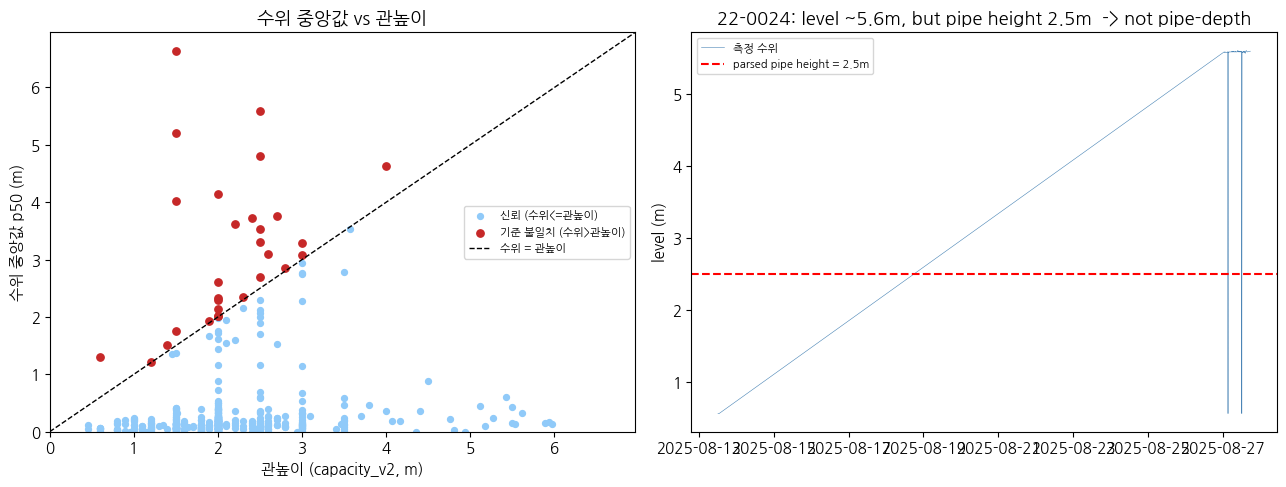

saved reports/figures_sewer/03_capacity_recalib.png


In [3]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
# (A) p50 수위 vs 관높이: y=x 위(빨강)=불가능 영역
ok=cap[~cap.datum_bad]; bd=cap[cap.datum_bad]
ax[0].scatter(ok.capacity_v2,ok.p50,s=18,c='#90caf9',label='신뢰 (수위<=관높이)')
ax[0].scatter(bd.capacity_v2,bd.p50,s=28,c='#c62828',label='기준 불일치 (수위>관높이)')
lim=[0,cap[['capacity_v2','p50']].max().max()*1.05]
ax[0].plot(lim,lim,'k--',lw=1,label='수위 = 관높이')
ax[0].set_xlabel('관높이 (capacity_v2, m)'); ax[0].set_ylabel('수위 중앙값 p50 (m)')
ax[0].set_title('수위 중앙값 vs 관높이'); ax[0].legend(fontsize=8); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
# (B) 대표 예시 22-0024: 관높이 2.5m인데 수위가 5.6m에 거의 일정
ex='22-0024'; d=sf[sf.sewer_sensor_id==ex].sort_values('ts10')
h=cap.loc[cap.sensor_id==ex,'capacity_v2'].iloc[0]
ax[1].plot(d.ts10,d.level_max_10m,lw=0.4,c='steelblue',label='측정 수위')
ax[1].axhline(h,ls='--',c='r',label=f'parsed pipe height = {h}m')
ax[1].set_title(f'{ex}: level ~5.6m, but pipe height {h}m  -> not pipe-depth')
ax[1].set_ylabel('level (m)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('reports/figures_sewer/03_capacity_recalib.png',dpi=110,bbox_inches='tight'); plt.show()
print('saved reports/figures_sewer/03_capacity_recalib.png')

## 3. 신뢰 capacity 센서만으로 surcharge 진위감사 재실행

In [4]:
reliable=set(cap.loc[cap.capacity_판정=='신뢰','sensor_id'])
sfr=sf[sf.sewer_sensor_id.isin(reliable)]
S=sfr[sfr.is_surcharge==1].copy(); S['year']=S.ts10.dt.year
fillmed=sfr.groupby('sewer_sensor_id').fill_rate.median().rename('fill_med_all')
ov=S.groupby('sewer_sensor_id').agg(n_surch=('ts10','size'),
    frac_2024p=('year',lambda x:(x>=2024).mean()),
    overshoot=('fill_rate',lambda x:(x>1.05).mean()),
    pinned1=('fill_rate',lambda x:(np.abs(x-1)<1e-6).mean()),
    stuck_in_s=('is_stuck_seg','mean'))
m=pd.read_parquet("dataset/processed/sewer_rain_mapping.parquet")[['sensor_id','rain_station_id']]
rf=pd.read_parquet(EB+"rain_features_10min.parquet",columns=['station_id','timestamp','is_recent_rain_6h'])
X=sfr.merge(m,left_on='sewer_sensor_id',right_on='sensor_id',how='left').merge(
   rf,left_on=['rain_station_id','ts10'],right_on=['station_id','timestamp'],how='left')
X=X[X.is_recent_rain_6h.notna()]
def lf(d):
    b=d.is_recent_rain_6h.mean(); s=d[d.is_surcharge==1]
    return pd.Series({'n_cov_surch':len(s),'lift':(s.is_recent_rain_6h.mean()/b) if(len(s)>0 and b>0) else np.nan})
A=ov.join(fillmed).join(X.groupby('sewer_sensor_id').apply(lf)).reset_index()
def cl(r):
    if (r.n_cov_surch>=30) and (r.lift>=2): return '진짜_강우성만관'
    if r.pinned1>=0.8: return 'stuck_천장'
    if r.stuck_in_s>=0.6: return 'stuck_구간'
    if (r.frac_2024p<0.2) or (r.n_cov_surch<30): return '미검증'
    return '비강우_모호'
A['판정']=A.apply(cl,axis=1)
print(A.판정.value_counts().to_string())
print('\n진짜 강우성 만관:', A[A.판정=='진짜_강우성만관'].sewer_sensor_id.tolist())

판정
미검증         79
stuck_천장    77
비강우_모호      31
stuck_구간     4
진짜_강우성만관     3

진짜 강우성 만관: ['06-0009', '11-0004', '20-0012']


## 4. 산출물 저장

In [5]:
cap.to_parquet(EB+"sewer_capacity_reliability.parquet",index=False)
A.to_parquet(EB+"sewer_surcharge_audit.parquet",index=False)   # 신뢰 capacity 기준으로 갱신
print('저장: sewer_capacity_reliability.parquet (485), sewer_surcharge_audit.parquet', len(A))

저장: sewer_capacity_reliability.parquet (485), sewer_surcharge_audit.parquet 194


## 결론
- **capacity 신뢰 455 / 기준 불일치 29 / 미상 1.** "capacity에러"의 정체는 **센서 불량이 아니라 측정 기준 불일치** — 그 29센서의 '수위'는 관내 물깊이가 아니라 다른 기준(표고/오프셋)으로 측정돼 fill_rate가 성립하지 않는다(예: 22-0024는 관높이 2.5m인데 수위가 5.6m에 거의 일정). 수위 데이터 자체가 망가진 게 아님.
- **이 29센서를 제외하면 capacity에러 범주가 사라진다.** 다만 surcharge 정의가 적용 안 되는 것뿐, 데이터 폐기는 아님(향후 기준 정보 확보 시 재영점화 가능).
- **진짜 강우성 만관은 여전히 3센서(20-0012·06-0009·11-0004)** — capacity 교정으로 새로 살아난 진짜 센서는 없음. 즉 capacity 문제는 *허위 surcharge를 만든* 것이지 *진짜를 가린* 것은 아니었다.
- 다음 레버는 **AWS 1분 강우 재검증**(비강우_모호 31 + 미검증의 2024+ 부분) — 국지호우로 추가 진짜 센서를 찾는다.